In [28]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import os

In [29]:
os.makedirs("lab5/data", exist_ok=True)
os.makedirs("lab5/tests", exist_ok=True)

создание датасетов

In [30]:
np.random.seed(42)

for i in range(1,4):

    x=np.random.randint(0,100,100)

    y=3*x+5+np.random.normal(0,3,100)

    df=pd.DataFrame({
        "x":x,
        "y":y
    })

    df.to_csv(
        f"lab5/data/dataset{i}.csv",
        index=False
    )

print("Датасеты созданы")

Датасеты созданы


шумный датасет

In [31]:
x=np.random.randint(0,100,100)

y=3*x+5+np.random.normal(0,30,100)

df=pd.DataFrame({
    "x":x,
    "y":y
})

df.to_csv(
    "lab5/data/noisy_dataset.csv",
    index=False
)

print("Шумный датасет создан")

Шумный датасет создан


обучение модели

In [32]:
data=pd.read_csv("lab5/data/dataset1.csv")

X=data[["x"]]
y=data["y"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model=LinearRegression()

model.fit(X_train,y_train)

pred=model.predict(X_test)

score=r2_score(
    y_test,
    pred
)

print("R2:",score)

R2: 0.9988053573419177


сохранение модели

In [33]:
import joblib

joblib.dump(
    model,
    "lab5/model.pkl"
)

['lab5/model.pkl']

создание тестового файла pytest

In [34]:
test_code='''
import joblib
import pandas as pd
from sklearn.metrics import r2_score

model=joblib.load("lab5/model.pkl")

def evaluate(dataset):

    data=pd.read_csv(dataset)

    X=data[["x"]]
    y=data["y"]

    pred=model.predict(X)

    return r2_score(y,pred)


def test_dataset1():

    assert evaluate(
        "lab5/data/dataset1.csv"
    )>0.95


def test_dataset2():

    assert evaluate(
        "lab5/data/dataset2.csv"
    )>0.95


def test_dataset3():

    assert evaluate(
        "lab5/data/dataset3.csv"
    )>0.95


def test_noisy_dataset():

    assert evaluate(
        "lab5/data/noisy_dataset.csv"
    )>0.95
'''

with open(
    "lab5/tests/test_model.py",
    "w",
    encoding="utf8"
) as f:

    f.write(test_code)

print("Файл тестов создан")

Файл тестов создан


запуск тестов

In [35]:
!pytest lab5/tests -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.13.0, typeguard-4.5.1, langsmith-0.7.34
collected 4 items                                                              

lab5/tests/test_model.py::test_dataset1 PASSED                           [ 25%]
lab5/tests/test_model.py::test_dataset2 PASSED                           [ 50%]
lab5/tests/test_model.py::test_dataset3 PASSED                           [ 75%]
lab5/tests/test_model.py::test_noisy_dataset FAILED                      [100%]

=================================== FAILURES ===================================
______________________________ test_noisy_dataset ______________________________

    def test_noisy_dataset():
    
>       assert evaluate(
            "lab5/data/noisy_dataset.csv"
        )>0.95
E       AssertionError: assert 0.8589719855957603 > 0.95


In [36]:
import joblib
import pandas as pd
from sklearn.metrics import r2_score

model = joblib.load("lab5/model.pkl")

def evaluate(dataset):

    data = pd.read_csv(dataset)

    X = data[["x"]]
    y = data["y"]

    pred = model.predict(X)

    return r2_score(y, pred)

вывод скора у шумного датасета

In [37]:
score=evaluate(
    "lab5/data/noisy_dataset.csv"
)

print(
    f"R2 шумного датасета: {score}"
)

R2 шумного датасета: 0.8589719855957603


визуализация датасетов

In [38]:
import matplotlib.pyplot as plt

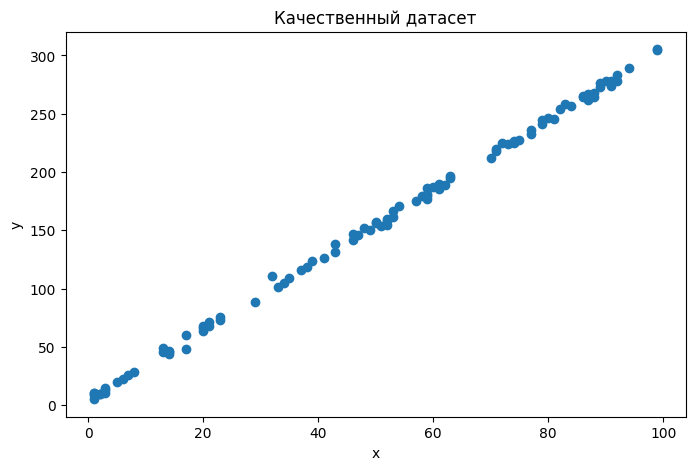

In [39]:
data = pd.read_csv("lab5/data/dataset1.csv")

plt.figure(figsize=(8,5))

plt.scatter(
    data["x"],
    data["y"]
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Качественный датасет")

plt.show()

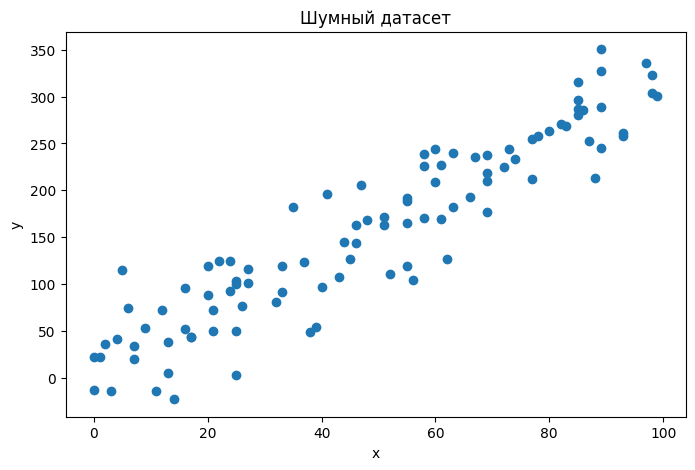

In [40]:
noisy = pd.read_csv(
    "lab5/data/noisy_dataset.csv"
)

plt.figure(figsize=(8,5))

plt.scatter(
    noisy["x"],
    noisy["y"]
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Шумный датасет")

plt.show()